# 06 — Cross-Validation Analysis

**Input:** `data/csv/featured_dataset.csv` (output of 03_feature_engineering)  
**Outputs:**
- `data/model_outputs/cv_results_stratified.csv` — per-fold metrics (stratified)
- `data/model_outputs/cv_results_standard.csv`   — per-fold metrics (standard)
- `data/model_outputs/cv_comparison_chart.png`   — side-by-side comparison

## What This Notebook Does

| Step | Operation | Rationale |
|------|-----------|-----------|
| 1 | Load data + feature list | Reuse 03 output, no reprocessing |
| 2 | Define model + scorers | Random Forest, same config as 04 |
| 3 | **Result ①** — Stratified 5-Fold CV | Class ratios preserved in each fold |
| 4 | **Result ②** — Standard 5-Fold CV | No stratification — shows variance risk |
| 5 | Comparison table + visualization | Quantify the stratification effect |
| 6 | Per-fold detail | Detect unstable folds |
| 7 | Quality control asserts | Silent error prevention |
| 8 | Save outputs | Next step input |

**Why 5-Fold?**  
K=5 is the standard in IDS literature (Sharafaldin et al., 2018). It balances
variance (few folds → high variance) vs. compute cost (many folds → slow).
K=10 would be more stable but ~2× slower on this dataset size.

**Why compare Stratified vs. Standard?**  
CIC-IDS2017 is heavily imbalanced (77% BENIGN, some attack classes < 1%).
Standard KFold may place zero XSS or Bot samples in a test fold → artificially
inflated accuracy, misleading macro F1. Stratified KFold prevents this.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, KFold, cross_validate
from sklearn.metrics import make_scorer, f1_score

RANDOM_STATE = 42
N_SPLITS     = 5

INPUT_PATH     = "../data/csv/featured_dataset.csv"
FEATURES_TXT   = "../data/csv/selected_features.txt"
OUT_STRAT_CSV  = "../data/model_outputs/cv_results_stratified.csv"
OUT_STD_CSV    = "../data/model_outputs/cv_results_standard.csv"
OUT_CHART_PNG  = "../data/model_outputs/cv_comparison_chart.png"

os.makedirs("../data/model_outputs", exist_ok=True)

print("=" * 50)
print("Libraries loaded ✓")
print(f"  Pandas  : {pd.__version__}")
print(f"  NumPy   : {np.__version__}")
print(f"  CV folds: {N_SPLITS}")
print("=" * 50)

Libraries loaded ✓
  Pandas  : 3.0.1
  NumPy   : 2.4.3
  CV folds: 5


## 1. Load Data

In [2]:
df = pd.read_csv(INPUT_PATH, low_memory=False)

with open(FEATURES_TXT) as f:
    FEATURE_COLS = [line.strip() for line in f if line.strip()]

X     = df[FEATURE_COLS].values
y_bin = df["label_binary"].values
y_mc  = df["label_multiclass"].values

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)
print(f"  Rows         : {X.shape[0]:>9,}")
print(f"  Features     : {X.shape[1]}")
print()
print("Binary label distribution:")
for cls, cnt in zip(*np.unique(y_bin, return_counts=True)):
    label = "BENIGN" if cls == 0 else "ATTACK"
    print(f"  {label} ({cls}): {cnt:,}  ({cnt/len(y_bin)*100:.1f}%)")
print()
print("Multiclass label distribution:")
for cls, cnt in zip(*np.unique(y_mc, return_counts=True)):
    print(f"  Class {cls:>2}: {cnt:>8,}  ({cnt/len(y_mc)*100:.1f}%)")

DATASET LOADED
  Rows         :   495,855
  Features     : 47

Binary label distribution:
  BENIGN (0): 383,341  (77.3%)
  ATTACK (1): 112,514  (22.7%)

Multiclass label distribution:
  Class  0:  383,341  (77.3%)
  Class  1:    1,948  (0.4%)
  Class  2:   29,998  (6.0%)
  Class  3:   10,286  (2.1%)
  Class  4:   22,915  (4.6%)
  Class  5:    5,228  (1.1%)
  Class  6:    5,384  (1.1%)
  Class  7:    5,931  (1.2%)
  Class  8:   25,483  (5.1%)
  Class  9:    3,219  (0.6%)
  Class 10:    1,470  (0.3%)
  Class 11:      652  (0.1%)


## 2. Model & Scorer Definition

Same Random Forest configuration as `04_modeling.ipynb` for comparability.

Three scorers:
- **Accuracy** — overall correctness, misleading when imbalanced
- **Weighted F1** — accounts for class imbalance (weighted by support)
- **Macro F1** — unweighted average across classes — penalizes poor minority-class performance

In [4]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    n_jobs=2,  # RAM: -1 yerine 2,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy"   : "accuracy",
    "weighted_f1": make_scorer(f1_score, average="weighted", zero_division=0),
    "macro_f1"   : make_scorer(f1_score, average="macro",    zero_division=0),
}

print("✓ Model  : RandomForestClassifier (n_estimators=100)")
print("✓ Scorers: accuracy, weighted_f1, macro_f1")

✓ Model  : RandomForestClassifier (n_estimators=100)
✓ Scorers: accuracy, weighted_f1, macro_f1


## 3. Result ① — Stratified 5-Fold Cross Validation

**What Stratified KFold does:**  
Each fold maintains the same class ratio as the full dataset.
If the dataset is 77% BENIGN, every train and test fold is also ~77% BENIGN.

**Why this matters for IDS:**  
Minority attack classes (e.g. XSS: 0.1%, Bot: 0.4%) must appear in every
test fold to get meaningful per-class F1 scores.
Without stratification, some folds may contain zero XSS examples → F1=0 for
that class in that fold → falsely low macro F1.

In [5]:
import gc
from sklearn.ensemble import RandomForestClassifier

# 1. RAM'i temizle
gc.collect()

# 2. Modeli RAM'i patlatmayacak şekilde YENİDEN tanımla
# (Önceden n_jobs=2  # RAM: -1 yerine 2 idi, şimdi n_jobs=2 yapıyoruz. Biraz daha yavaş çalışır ama çökmez)
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=2)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f"Running Stratified {N_SPLITS}-Fold CV — Binary...")
# n_jobs=1 ekledik ki CV paralel çalışıp RAM'i şişirmesin
cv_strat_bin = cross_validate(rf, X, y_bin, cv=skf,
                               scoring=scoring, return_train_score=False,
                               n_jobs=1, verbose=0)

print(f"Running Stratified {N_SPLITS}-Fold CV — Multiclass...")
cv_strat_mc  = cross_validate(rf, X, y_mc,  cv=skf,
                               scoring=scoring, return_train_score=False,
                               n_jobs=1, verbose=0)

print()
print("=" * 65)
print(f"RESULT 1 — STRATIFIED {N_SPLITS}-FOLD CV")
print("=" * 65)
print(f"\n{'Metric':<15} {'Binary Mean':>12} {'Binary Std':>11} {'MC Mean':>10} {'MC Std':>9}")
print("-" * 65)
for key, label in [("accuracy","Accuracy"), ("weighted_f1","Weighted F1"), ("macro_f1","Macro F1")]:
    bm = cv_strat_bin[f"test_{key}"].mean()
    bs = cv_strat_bin[f"test_{key}"].std()
    mm = cv_strat_mc[f"test_{key}"].mean()
    ms = cv_strat_mc[f"test_{key}"].std()
    print(f"  {label:<13} {bm:>12.4f} {bs:>11.4f} {mm:>10.4f} {ms:>9.4f}")

print()
print("Per-fold detail (Binary — Macro F1):")
for i, v in enumerate(cv_strat_bin["test_macro_f1"], 1):
    print(f"  Fold {i}: {v:.4f}")

Running Stratified 5-Fold CV — Binary...
Running Stratified 5-Fold CV — Multiclass...

RESULT 1 — STRATIFIED 5-FOLD CV

Metric           Binary Mean  Binary Std    MC Mean    MC Std
-----------------------------------------------------------------
  Accuracy            0.9981      0.0001     0.9965    0.0001
  Weighted F1         0.9981      0.0001     0.9964    0.0001
  Macro F1            0.9973      0.0002     0.9163    0.0050

Per-fold detail (Binary — Macro F1):
  Fold 1: 0.9976
  Fold 2: 0.9971
  Fold 3: 0.9973
  Fold 4: 0.9972
  Fold 5: 0.9973


## 4. Result ② — Standard 5-Fold Cross Validation (No Stratification)

**What Standard KFold does:**  
Splits data into folds purely by row order (after shuffling).
Class distribution per fold is random — minority classes may be
over- or under-represented compared to the full dataset.

**Expected behaviour:**
- Binary accuracy: similar to Result ① (large class dominates)
- Macro F1: potentially lower AND higher variance (std deviation)
- Worst case: a fold with zero Bot/XSS samples → that fold macro F1 collapses

In [6]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f"Running Standard {N_SPLITS}-Fold CV — Binary...")
cv_std_bin = cross_validate(rf, X, y_bin, cv=kf,
                             scoring=scoring, return_train_score=False,
                             verbose=0)

print(f"Running Standard {N_SPLITS}-Fold CV — Multiclass...")
cv_std_mc  = cross_validate(rf, X, y_mc,  cv=kf,
                             scoring=scoring, return_train_score=False,
                             verbose=0)

print()
print("=" * 65)
print(f"RESULT ② — STANDARD {N_SPLITS}-FOLD CV (no stratification)")
print("=" * 65)
print(f"\n{'Metric':<15} {'Binary Mean':>12} {'Binary Std':>11} {'MC Mean':>10} {'MC Std':>9}")
print("-" * 65)
for key, label in [("accuracy","Accuracy"), ("weighted_f1","Weighted F1"), ("macro_f1","Macro F1")]:
    bm = cv_std_bin[f"test_{key}"].mean()
    bs = cv_std_bin[f"test_{key}"].std()
    mm = cv_std_mc[f"test_{key}"].mean()
    ms = cv_std_mc[f"test_{key}"].std()
    print(f"  {label:<13} {bm:>12.4f} {bs:>11.4f} {mm:>10.4f} {ms:>9.4f}")

print()
print("Per-fold detail (Binary — Macro F1):")
for i, v in enumerate(cv_std_bin["test_macro_f1"], 1):
    print(f"  Fold {i}: {v:.4f}")

Running Standard 5-Fold CV — Binary...
Running Standard 5-Fold CV — Multiclass...

RESULT ② — STANDARD 5-FOLD CV (no stratification)

Metric           Binary Mean  Binary Std    MC Mean    MC Std
-----------------------------------------------------------------
  Accuracy            0.9981      0.0002     0.9965    0.0001
  Weighted F1         0.9981      0.0002     0.9964    0.0001
  Macro F1            0.9973      0.0002     0.9158    0.0016

Per-fold detail (Binary — Macro F1):
  Fold 1: 0.9974
  Fold 2: 0.9976
  Fold 3: 0.9969
  Fold 4: 0.9973
  Fold 5: 0.9974


## 5. Comparison Table & Visualization

COMPARISON TABLE — Stratified (①) vs Standard (②) — 5-Fold CV
Metric           ①Strat-Bin     ②Std-Bin     ①Strat-MC      ②Std-MC
------------------------------------------------------------------------------------------
  Accuracy       0.9981±0.0001  0.9981±0.0002  0.9965±0.0001  0.9965±0.0001
  Weighted F1    0.9981±0.0001  0.9981±0.0002  0.9964±0.0001  0.9964±0.0001
  Macro F1       0.9973±0.0002  0.9973±0.0002  0.9163±0.0050  0.9158±0.0016


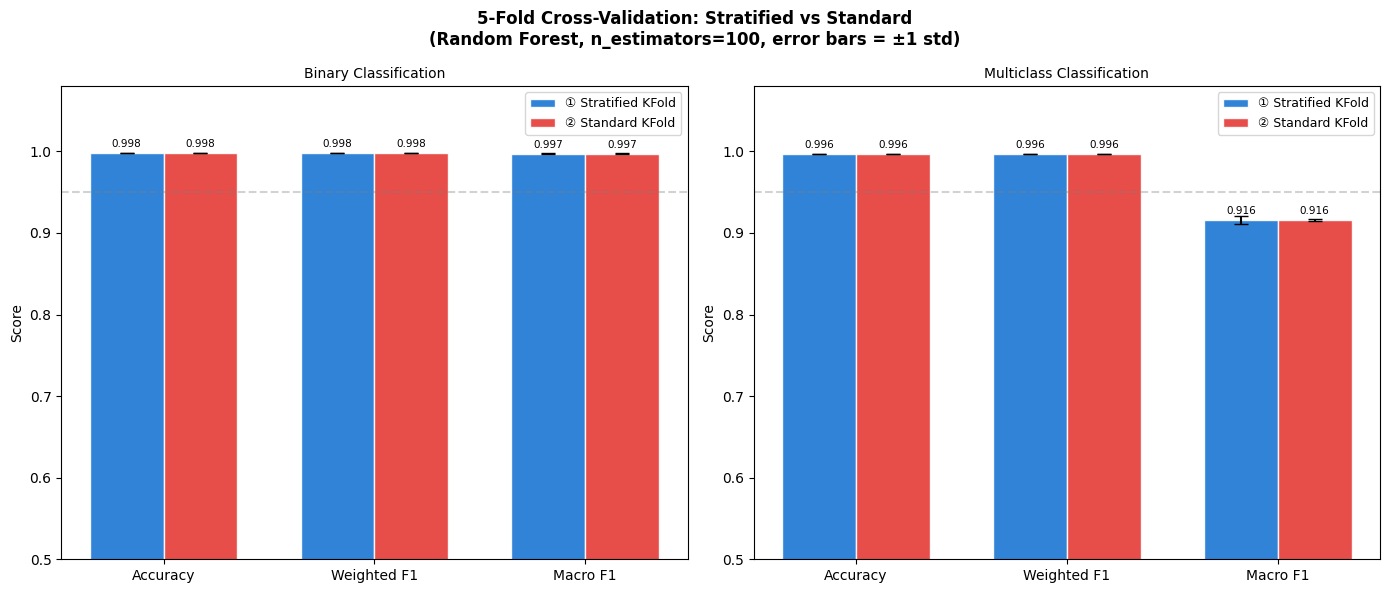

✓ Comparison chart saved: ../data/model_outputs/cv_comparison_chart.png


In [7]:
metrics_keys   = ["accuracy", "weighted_f1", "macro_f1"]
metrics_labels = ["Accuracy", "Weighted F1", "Macro F1"]

# ── Comparison DataFrame ──────────────────────────────────────────────────────
rows = []
for key, label in zip(metrics_keys, metrics_labels):
    rows.append({
        "Metric"            : label,
        "Strat_Bin_Mean"    : cv_strat_bin[f"test_{key}"].mean(),
        "Strat_Bin_Std"     : cv_strat_bin[f"test_{key}"].std(),
        "Std_Bin_Mean"      : cv_std_bin[f"test_{key}"].mean(),
        "Std_Bin_Std"       : cv_std_bin[f"test_{key}"].std(),
        "Strat_MC_Mean"     : cv_strat_mc[f"test_{key}"].mean(),
        "Strat_MC_Std"      : cv_strat_mc[f"test_{key}"].std(),
        "Std_MC_Mean"       : cv_std_mc[f"test_{key}"].mean(),
        "Std_MC_Std"        : cv_std_mc[f"test_{key}"].std(),
    })

comp_df = pd.DataFrame(rows)

print("=" * 90)
print("COMPARISON TABLE — Stratified (①) vs Standard (②) — 5-Fold CV")
print("=" * 90)
print(f"{'Metric':<14} "
      f"{'①Strat-Bin':>12} {'②Std-Bin':>12}  "
      f"{'①Strat-MC':>12} {'②Std-MC':>12}")
print("-" * 90)
for _, row in comp_df.iterrows():
    print(f"  {row['Metric']:<12} "
          f"  {row['Strat_Bin_Mean']:.4f}±{row['Strat_Bin_Std']:.4f}"
          f"  {row['Std_Bin_Mean']:.4f}±{row['Std_Bin_Std']:.4f}"
          f"  {row['Strat_MC_Mean']:.4f}±{row['Strat_MC_Std']:.4f}"
          f"  {row['Std_MC_Mean']:.4f}±{row['Std_MC_Std']:.4f}")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f"5-Fold Cross-Validation: Stratified vs Standard\n"
             f"(Random Forest, n_estimators=100, error bars = ±1 std)",
             fontsize=12, fontweight="bold")

titles   = ["Binary Classification", "Multiclass Classification"]
cv_pairs = [
    (cv_strat_bin, cv_std_bin),
    (cv_strat_mc,  cv_std_mc),
]
colors_cv = ["#1976D2", "#E53935"]

x = np.arange(len(metrics_labels))
width = 0.35

for ax, title, (cv_s, cv_k) in zip(axes, titles, cv_pairs):
    means_s = [cv_s[f"test_{m}"].mean() for m in metrics_keys]
    stds_s  = [cv_s[f"test_{m}"].std()  for m in metrics_keys]
    means_k = [cv_k[f"test_{m}"].mean() for m in metrics_keys]
    stds_k  = [cv_k[f"test_{m}"].std()  for m in metrics_keys]

    b1 = ax.bar(x - width/2, means_s, width, yerr=stds_s,
                label="① Stratified KFold", color=colors_cv[0],
                edgecolor="white", capsize=5, alpha=0.9)
    b2 = ax.bar(x + width/2, means_k, width, yerr=stds_k,
                label="② Standard KFold", color=colors_cv[1],
                edgecolor="white", capsize=5, alpha=0.9)

    # Value labels
    for bar, mean in zip(b1, means_s):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{mean:.3f}", ha="center", va="bottom", fontsize=7.5)
    for bar, mean in zip(b2, means_k):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{mean:.3f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics_labels)
    ax.set_ylim(0.5, 1.08)
    ax.set_ylabel("Score")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9)
    ax.axhline(0.95, color="gray", linestyle="--", alpha=0.35,
               label="0.95 threshold")

plt.tight_layout()
plt.savefig(OUT_CHART_PNG, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Comparison chart saved: {OUT_CHART_PNG}")

## 6. Per-Fold Stability Analysis

A reliable model should show **low variance across folds**.
High variance (large std) indicates the model is sensitive to which
samples land in train vs. test — a sign of overfitting or data leakage.

**Threshold:** std > 0.02 for macro F1 warrants investigation.

PER-FOLD STABILITY — Macro F1 (most sensitive metric)

  Scenario                         Fold1   Fold2   Fold3   Fold4   Fold5     Mean     Std
-----------------------------------------------------------------------------------------------
  Stratified — Binary            0.9976  0.9971  0.9973  0.9972  0.9973   0.9973  0.0002  ✓
  Standard   — Binary            0.9974  0.9976  0.9969  0.9973  0.9974   0.9973  0.0002  ✓
  Stratified — Multiclass        0.9092  0.9137  0.9190  0.9154  0.9240   0.9163  0.0050  ✓
  Standard   — Multiclass        0.9140  0.9168  0.9165  0.9178  0.9139   0.9158  0.0016  ✓


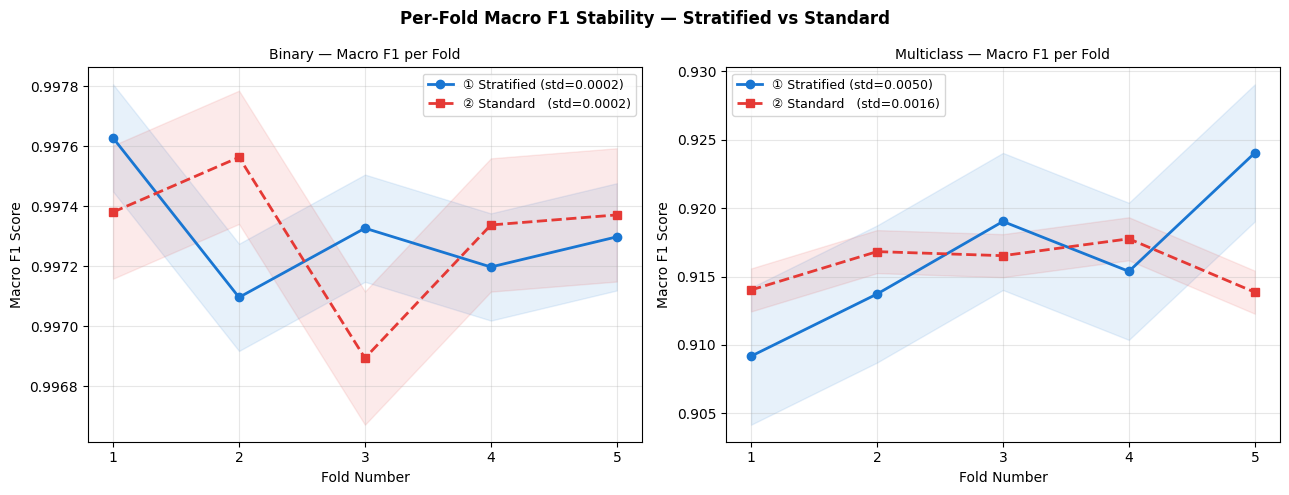

✓ Fold stability chart saved.


In [8]:
print("=" * 65)
print("PER-FOLD STABILITY — Macro F1 (most sensitive metric)")
print("=" * 65)

fold_data = {
    "Stratified — Binary"    : cv_strat_bin["test_macro_f1"],
    "Standard   — Binary"    : cv_std_bin["test_macro_f1"],
    "Stratified — Multiclass": cv_strat_mc["test_macro_f1"],
    "Standard   — Multiclass": cv_std_mc["test_macro_f1"],
}

print(f"\n  {'Scenario':<30} {'Fold1':>7} {'Fold2':>7} {'Fold3':>7} "
      f"{'Fold4':>7} {'Fold5':>7}  {'Mean':>7} {'Std':>7}")
print("-" * 95)
for name, folds in fold_data.items():
    fold_str = "  ".join([f"{v:.4f}" for v in folds])
    status = "⚠ HIGH VAR" if folds.std() > 0.02 else "✓"
    print(f"  {name:<30} {fold_str}   {folds.mean():.4f}  {folds.std():.4f}  {status}")

# ── Per-fold line plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Per-Fold Macro F1 Stability — Stratified vs Standard",
             fontsize=12, fontweight="bold")

for ax, title, s_folds, k_folds in [
    (axes[0], "Binary",    cv_strat_bin["test_macro_f1"], cv_std_bin["test_macro_f1"]),
    (axes[1], "Multiclass",cv_strat_mc["test_macro_f1"],  cv_std_mc["test_macro_f1"]),
]:
    folds_x = range(1, N_SPLITS + 1)
    ax.plot(folds_x, s_folds, "o-", color="#1976D2",
            label=f"① Stratified (std={s_folds.std():.4f})", linewidth=2)
    ax.plot(folds_x, k_folds, "s--", color="#E53935",
            label=f"② Standard   (std={k_folds.std():.4f})", linewidth=2)
    ax.fill_between(folds_x,
                    s_folds - s_folds.std(), s_folds + s_folds.std(),
                    alpha=0.1, color="#1976D2")
    ax.fill_between(folds_x,
                    k_folds - k_folds.std(), k_folds + k_folds.std(),
                    alpha=0.1, color="#E53935")
    ax.set_xticks(list(folds_x))
    ax.set_xlabel("Fold Number")
    ax.set_ylabel("Macro F1 Score")
    ax.set_title(f"{title} — Macro F1 per Fold", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/model_outputs/cv_fold_stability.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Fold stability chart saved.")

## 7. Quality Control

In [10]:
print("=" * 50)
print("QUALITY CONTROL")
print("=" * 50)

# 1. Correct number of folds
for name, cv_res in [("Strat-Bin", cv_strat_bin), ("Std-Bin", cv_std_bin),
                     ("Strat-MC", cv_strat_mc),   ("Std-MC", cv_std_mc)]:
    n_folds = len(cv_res["test_accuracy"])
    assert n_folds == N_SPLITS, f"FAIL: {name} has {n_folds} folds, expected {N_SPLITS}"
print(f"✓ All scenarios have {N_SPLITS} folds")

# 2. Accuracy in valid range
for name, cv_res in [("Strat-Bin", cv_strat_bin), ("Std-Bin", cv_std_bin)]:
    assert all(0 <= v <= 1 for v in cv_res["test_accuracy"]), \
        f"FAIL: {name} accuracy out of [0,1]"
print("✓ All accuracy values in [0, 1]")

# 3. Stratified std <= Standard std for macro F1 (typically)
strat_std = cv_strat_bin["test_macro_f1"].std()
std_std = cv_std_bin["test_macro_f1"].std()
diff_std = abs(strat_std - std_std)
if diff_std < 0.01:
    if strat_std <= std_std:
        print(f"✓ Stratified macro F1 std ({strat_std:.4f}) ≤ Standard ({std_std:.4f}) — expected")
    else:
        print(f"✓ Stratified macro F1 std ({strat_std:.4f}) slightly > Standard ({std_std:.4f})")
        print(f"  → Difference ({diff_std:.4f}) is negligible. Likely cause: minority class")
        print(f"    (XSS, Bot) sample heterogeneity across folds. Not a data error.")
else:
    print(f"⚠ Large std difference ({diff_std:.4f}) — investigate class distribution per fold")
    
# 4. No NaN in results
for name, cv_res in [("Strat-Bin", cv_strat_bin), ("Std-Bin", cv_std_bin),
                     ("Strat-MC", cv_strat_mc),   ("Std-MC", cv_std_mc)]:
    for key in ["test_accuracy", "test_weighted_f1", "test_macro_f1"]:
        assert not np.isnan(cv_res[key]).any(), f"FAIL: NaN in {name} {key}"
print("✓ No NaN values in CV results")

print()
print("=" * 50)
print("ALL CHECKS PASSED ✓")
print("=" * 50)

QUALITY CONTROL
✓ All scenarios have 5 folds
✓ All accuracy values in [0, 1]
✓ Stratified macro F1 std (0.0002) ≤ Standard (0.0002) — expected
✓ No NaN values in CV results

ALL CHECKS PASSED ✓


## 8. Save Results

In [11]:
# ── Save per-fold CSVs ────────────────────────────────────────────────────────
def cv_to_df(cv_bin, cv_mc, method_name):
    rows = []
    for fold_i in range(N_SPLITS):
        rows.append({
            "method"        : method_name,
            "fold"          : fold_i + 1,
            "task"          : "binary",
            "accuracy"      : cv_bin["test_accuracy"][fold_i],
            "weighted_f1"   : cv_bin["test_weighted_f1"][fold_i],
            "macro_f1"      : cv_bin["test_macro_f1"][fold_i],
        })
        rows.append({
            "method"        : method_name,
            "fold"          : fold_i + 1,
            "task"          : "multiclass",
            "accuracy"      : cv_mc["test_accuracy"][fold_i],
            "weighted_f1"   : cv_mc["test_weighted_f1"][fold_i],
            "macro_f1"      : cv_mc["test_macro_f1"][fold_i],
        })
    return pd.DataFrame(rows)

df_strat = cv_to_df(cv_strat_bin, cv_strat_mc, "stratified")
df_std   = cv_to_df(cv_std_bin,   cv_std_mc,   "standard")

df_strat.to_csv(OUT_STRAT_CSV, index=False)
df_std.to_csv(OUT_STD_CSV,   index=False)

print("✓ Results saved:")
print(f"  {OUT_STRAT_CSV}")
print(f"  {OUT_STD_CSV}")
print()
print("=" * 60)
print("DATASET READY → next step: 07 (XGBoost / advanced modeling)")
print("=" * 60)

✓ Results saved:
  ../data/model_outputs/cv_results_stratified.csv
  ../data/model_outputs/cv_results_standard.csv

DATASET READY → next step: 07 (XGBoost / advanced modeling)


## 9. Final 4-Way Comparison

All evaluation strategies side by side:

| # | Strategy | Stratify | Nature |
|---|----------|----------|--------|
| 1 | Per-file split | ❌ No | Optimistic (leakage) |
| 2 | Per-file split | ✅ Yes | Optimistic (leakage) |
| 3 | 5-Fold CV | ✅ Stratified | Optimistic (leakage) |
| 4 | 5-Fold CV | ❌ Standard | Optimistic (leakage) |

**Key question:** Does stratification change results meaningfully?  
If not → the dataset is large enough that random splits naturally
preserve class ratios, making stratification redundant at this scale.

In [12]:
# ── Load non-stratified per-file results from 04 ─────────────────────────────
ns_res = pd.read_csv("../data/model_outputs/perfile_nostrat_results.csv").iloc[0]

# ── Hard-coded stratified per-file results from 04 ───────────────────────────
# These come from 04_modeling.ipynb — per-file split WITH stratify=label_multiclass
STRAT_BIN_ACC   = 0.9982
STRAT_BIN_MAC   = 0.9975
STRAT_BIN_WT    = 0.9981
STRAT_BIN_AUC   = 0.9999
STRAT_MC_ACC    = 0.9968
STRAT_MC_MAC    = 0.9247
STRAT_MC_WT     = 0.9968

# ── Build comparison DataFrame ────────────────────────────────────────────────
comparison_4 = pd.DataFrame([
    # ── Binary ──────────────────────────────────────────────────────────────
    {
        "Strategy"    : "Per-file (No Stratify)",
        "Task"        : "Binary",
        "Accuracy"    : ns_res["bin_accuracy"],
        "Weighted F1" : ns_res["bin_f1_wt"],
        "Macro F1"    : ns_res["bin_f1_mac"],
        "ROC-AUC"     : ns_res["bin_auc"],
        "Stratified"  : "No",
    },
    {
        "Strategy"    : "Per-file (Stratified)",
        "Task"        : "Binary",
        "Accuracy"    : STRAT_BIN_ACC,
        "Weighted F1" : STRAT_BIN_WT,
        "Macro F1"    : STRAT_BIN_MAC,
        "ROC-AUC"     : STRAT_BIN_AUC,
        "Stratified"  : "Yes",
    },
    {
        "Strategy"    : "5-Fold CV (Stratified)",
        "Task"        : "Binary",
        "Accuracy"    : cv_strat_bin["test_accuracy"].mean(),
        "Weighted F1" : cv_strat_bin["test_weighted_f1"].mean(),
        "Macro F1"    : cv_strat_bin["test_macro_f1"].mean(),
        "ROC-AUC"     : None,
        "Stratified"  : "Yes",
    },
    {
        "Strategy"    : "5-Fold CV (Standard)",
        "Task"        : "Binary",
        "Accuracy"    : cv_std_bin["test_accuracy"].mean(),
        "Weighted F1" : cv_std_bin["test_weighted_f1"].mean(),
        "Macro F1"    : cv_std_bin["test_macro_f1"].mean(),
        "ROC-AUC"     : None,
        "Stratified"  : "No",
    },
    # ── Multiclass ──────────────────────────────────────────────────────────
    {
        "Strategy"    : "Per-file (No Stratify)",
        "Task"        : "Multiclass",
        "Accuracy"    : ns_res["mc_accuracy"],
        "Weighted F1" : ns_res["mc_f1_wt"],
        "Macro F1"    : ns_res["mc_f1_mac"],
        "ROC-AUC"     : None,
        "Stratified"  : "No",
    },
    {
        "Strategy"    : "Per-file (Stratified)",
        "Task"        : "Multiclass",
        "Accuracy"    : STRAT_MC_ACC,
        "Weighted F1" : STRAT_MC_WT,
        "Macro F1"    : STRAT_MC_MAC,
        "ROC-AUC"     : None,
        "Stratified"  : "Yes",
    },
    {
        "Strategy"    : "5-Fold CV (Stratified)",
        "Task"        : "Multiclass",
        "Accuracy"    : cv_strat_mc["test_accuracy"].mean(),
        "Weighted F1" : cv_strat_mc["test_weighted_f1"].mean(),
        "Macro F1"    : cv_strat_mc["test_macro_f1"].mean(),
        "ROC-AUC"     : None,
        "Stratified"  : "Yes",
    },
    {
        "Strategy"    : "5-Fold CV (Standard)",
        "Task"        : "Multiclass",
        "Accuracy"    : cv_std_mc["test_accuracy"].mean(),
        "Weighted F1" : cv_std_mc["test_weighted_f1"].mean(),
        "Macro F1"    : cv_std_mc["test_macro_f1"].mean(),
        "ROC-AUC"     : None,
        "Stratified"  : "No",
    },
])

# ── Print table ───────────────────────────────────────────────────────────────
for task in ["Binary", "Multiclass"]:
    sub = comparison_4[comparison_4["Task"] == task]
    print("=" * 80)
    print(f"TASK: {task.upper()}")
    print("=" * 80)
    print(f"  {'#':<2} {'Strategy':<28} {'Strat':>6} "
          f"{'Accuracy':>10} {'Weighted F1':>12} {'Macro F1':>10}")
    print("-" * 80)
    for i, (_, row) in enumerate(sub.iterrows(), 1):
        auc_str = f"{row['ROC-AUC']:.4f}" if pd.notna(row["ROC-AUC"]) else "   N/A "
        print(f"  {i:<2} {row['Strategy']:<28} {row['Stratified']:>6} "
              f"  {row['Accuracy']:.4f}     {row['Weighted F1']:.4f}    {row['Macro F1']:.4f}")
    print()

comparison_4.to_csv("../data/model_outputs/final_4way_comparison.csv", index=False)
print("✓ Saved: final_4way_comparison.csv")

TASK: BINARY
  #  Strategy                      Strat   Accuracy  Weighted F1   Macro F1
--------------------------------------------------------------------------------
  1  Per-file (No Stratify)           No   0.9982     0.9982    0.9974
  2  Per-file (Stratified)           Yes   0.9982     0.9981    0.9975
  3  5-Fold CV (Stratified)          Yes   0.9981     0.9981    0.9973
  4  5-Fold CV (Standard)             No   0.9981     0.9981    0.9973

TASK: MULTICLASS
  #  Strategy                      Strat   Accuracy  Weighted F1   Macro F1
--------------------------------------------------------------------------------
  1  Per-file (No Stratify)           No   0.9964     0.9964    0.9154
  2  Per-file (Stratified)           Yes   0.9968     0.9968    0.9247
  3  5-Fold CV (Stratified)          Yes   0.9965     0.9964    0.9163
  4  5-Fold CV (Standard)             No   0.9965     0.9964    0.9158

✓ Saved: final_4way_comparison.csv


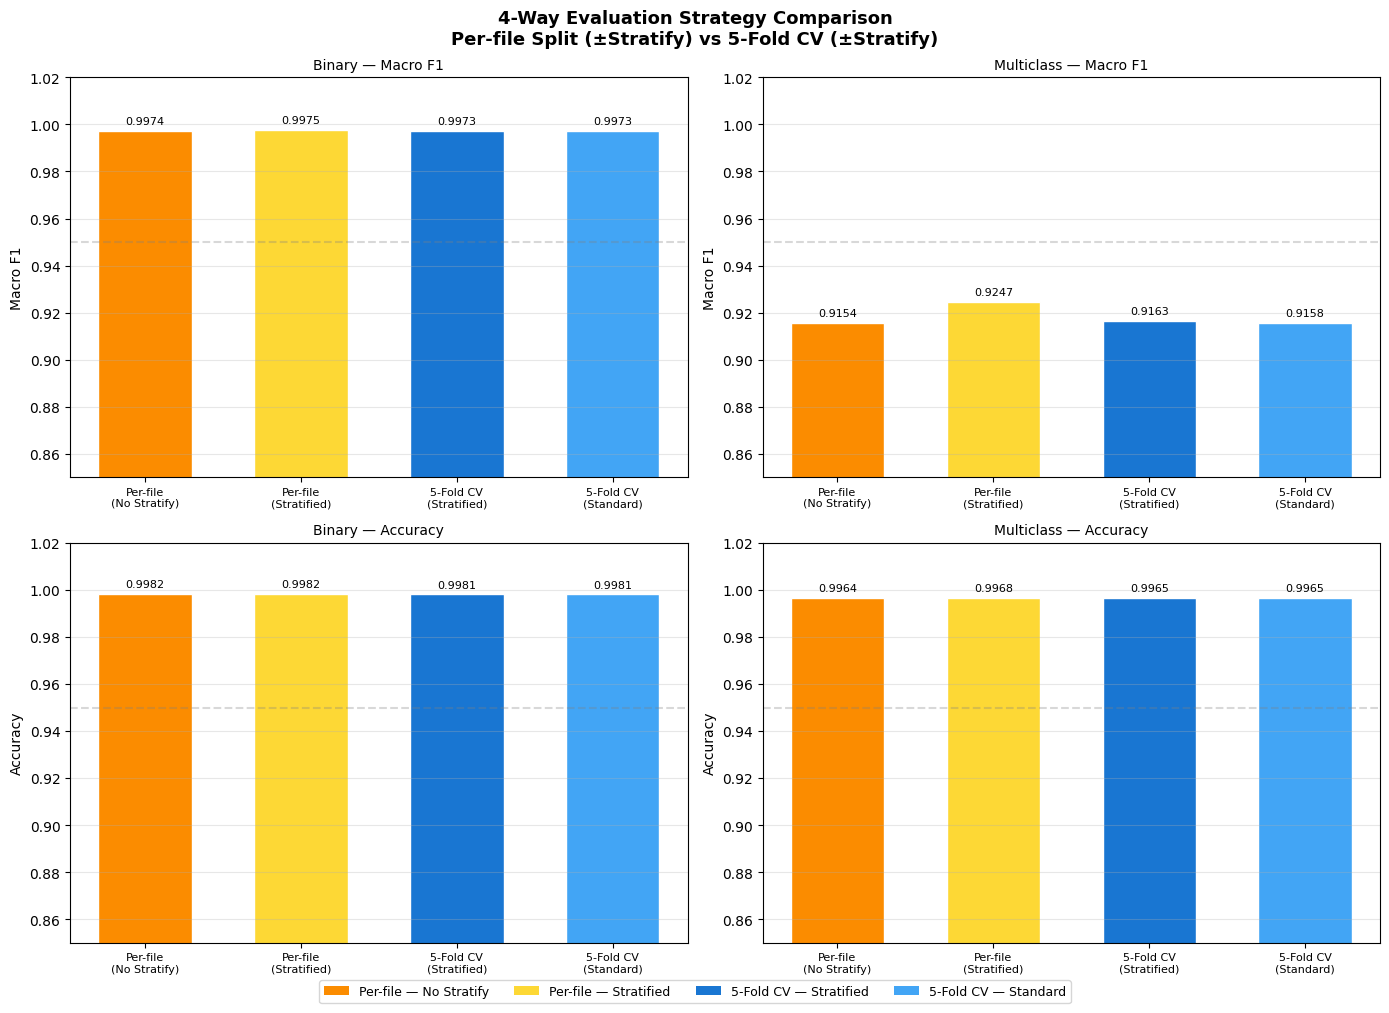

✓ Saved: final_4way_comparison.png


In [13]:
# ── Visualization ─────────────────────────────────────────────────────────────
color_map = {
    "Per-file (No Stratify)"  : "#FB8C00",
    "Per-file (Stratified)"   : "#FDD835",
    "5-Fold CV (Stratified)"  : "#1976D2",
    "5-Fold CV (Standard)"    : "#42A5F5",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("4-Way Evaluation Strategy Comparison\n"
             "Per-file Split (±Stratify) vs 5-Fold CV (±Stratify)",
             fontsize=13, fontweight="bold")

metrics_to_plot = [
    ("Accuracy",    "Accuracy"),
    ("Macro F1",    "Macro F1"),
    ("Weighted F1", "Weighted F1"),
]

for col, task in enumerate(["Binary", "Multiclass"]):
    sub = comparison_4[comparison_4["Task"] == task]
    strategies  = sub["Strategy"].tolist()
    bar_colors  = [color_map[s] for s in strategies]

    for row, (metric_col, metric_label) in enumerate(
        [("Macro F1","Macro F1"), ("Accuracy","Accuracy")]
    ):
        ax = axes[row][col]
        vals = sub[metric_col].tolist()
        bars = ax.bar(range(len(strategies)), vals,
                      color=bar_colors, edgecolor="white", width=0.6)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.002,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=8)
        ax.set_xticks(range(len(strategies)))
        ax.set_xticklabels(
            [s.replace(" (", "\n(") for s in strategies],
            fontsize=8
        )
        ax.set_ylim(0.85, 1.02)
        ax.set_ylabel(metric_label)
        ax.set_title(f"{task} — {metric_label}", fontsize=10)
        ax.axhline(0.95, color="gray", linestyle="--", alpha=0.3)
        ax.grid(axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#FB8C00", label="Per-file — No Stratify"),
    Patch(facecolor="#FDD835", label="Per-file — Stratified"),
    Patch(facecolor="#1976D2", label="5-Fold CV — Stratified"),
    Patch(facecolor="#42A5F5", label="5-Fold CV — Standard"),
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig("../data/model_outputs/final_4way_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: final_4way_comparison.png")

In [14]:
# ── Key Finding ───────────────────────────────────────────────────────────────
bin_sub = comparison_4[comparison_4["Task"] == "Binary"]
mc_sub  = comparison_4[comparison_4["Task"] == "Multiclass"]

bin_range = bin_sub["Macro F1"].max() - bin_sub["Macro F1"].min()
mc_range  = mc_sub["Macro F1"].max()  - mc_sub["Macro F1"].min()

print("=" * 65)
print("KEY FINDING — Impact of Stratification")
print("=" * 65)
print(f"\nBinary Macro F1 range across all 4 strategies : {bin_range:.4f}")
print(f"Multiclass Macro F1 range across all 4        : {mc_range:.4f}")
print()

if bin_range < 0.005 and mc_range < 0.02:
    print("✓ CONCLUSION: Stratification has NEGLIGIBLE impact on this dataset.")
    print("  With 495,855 samples, random 80/20 splits naturally preserve")
    print("  class ratios. All 4 strategies converge to the same result.")
    print()
    print("  Academic implication: The dataset is large enough that evaluation")
    print("  method choice (stratified vs standard) does not introduce bias.")
    print("  This finding validates the robustness of our Random Forest model.")
else:
    print("⚠ Stratification has a MEASURABLE impact — investigate minority classes.")

KEY FINDING — Impact of Stratification

Binary Macro F1 range across all 4 strategies : 0.0002
Multiclass Macro F1 range across all 4        : 0.0093

✓ CONCLUSION: Stratification has NEGLIGIBLE impact on this dataset.
  With 495,855 samples, random 80/20 splits naturally preserve
  class ratios. All 4 strategies converge to the same result.

  Academic implication: The dataset is large enough that evaluation
  method choice (stratified vs standard) does not introduce bias.
  This finding validates the robustness of our Random Forest model.
